#  Emotion Detection — Professional PyTorch Pipeline


## 1. Configuration — All hyperparameters in one place

In [1]:
import os

DATA_DIR    = r"D:\Internships\archive(1)"   
TRAIN_DIR   = os.path.join(DATA_DIR, "train")
TEST_DIR    = os.path.join(DATA_DIR, "test")

IMG_SIZE    = 48          
IN_CHANNELS = 1           

BATCH_SIZE      = 64
EPOCHS          = 50
LR              = 1e-3
LR_PATIENCE     = 5       
LR_FACTOR       = 0.5     
EARLY_STOP_PAT  = 10      
VAL_SPLIT       = 0.15   
WEIGHT_DECAY    = 1e-4
SEED=42

EMOTION_LABELS  = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
NUM_CLASSES     = len(EMOTION_LABELS)

MODEL_SAVE_PATH = "emotion_resnet18_best.pth"

print("Configuration loaded.")
print(f"  Emotion classes : {EMOTION_LABELS}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Max epochs      : {EPOCHS}")
print(f"  Learning rate   : {LR}")

Configuration loaded.
  Emotion classes : ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
  Batch size      : 64
  Max epochs      : 50
  Learning rate   : 0.001


## 2. Imports & Device Setup

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

#  Reproducibility 
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

#  Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
  GPU : NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM: 6.4 GB


## 3. Data Transforms & Augmentation

In [3]:

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),    
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),  
])


eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("Transforms ready.")
print(f"  Train augmentation steps : {len(train_transform.transforms)}")
print(f"  Eval transform steps     : {len(eval_transform.transforms)}")

Transforms ready.
  Train augmentation steps : 9
  Eval transform steps     : 4


## 4. Dataset Loading & Train/Val/Test Split

In [4]:

full_train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)

test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=eval_transform)


total_train = len(full_train_dataset)
val_size    = int(total_train * VAL_SPLIT)
train_size  = total_train - val_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

val_dataset.dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print("Dataset split complete:")
print(f"  Train samples : {train_size:,}")
print(f"  Val   samples : {val_size:,}")
print(f"  Test  samples : {len(test_dataset):,}")
print(f"  Classes       : {full_train_dataset.classes}")

Dataset split complete:
  Train samples : 24,403
  Val   samples : 4,306
  Test  samples : 7,178
  Classes       : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 5. Visualize Sample Images per Emotion

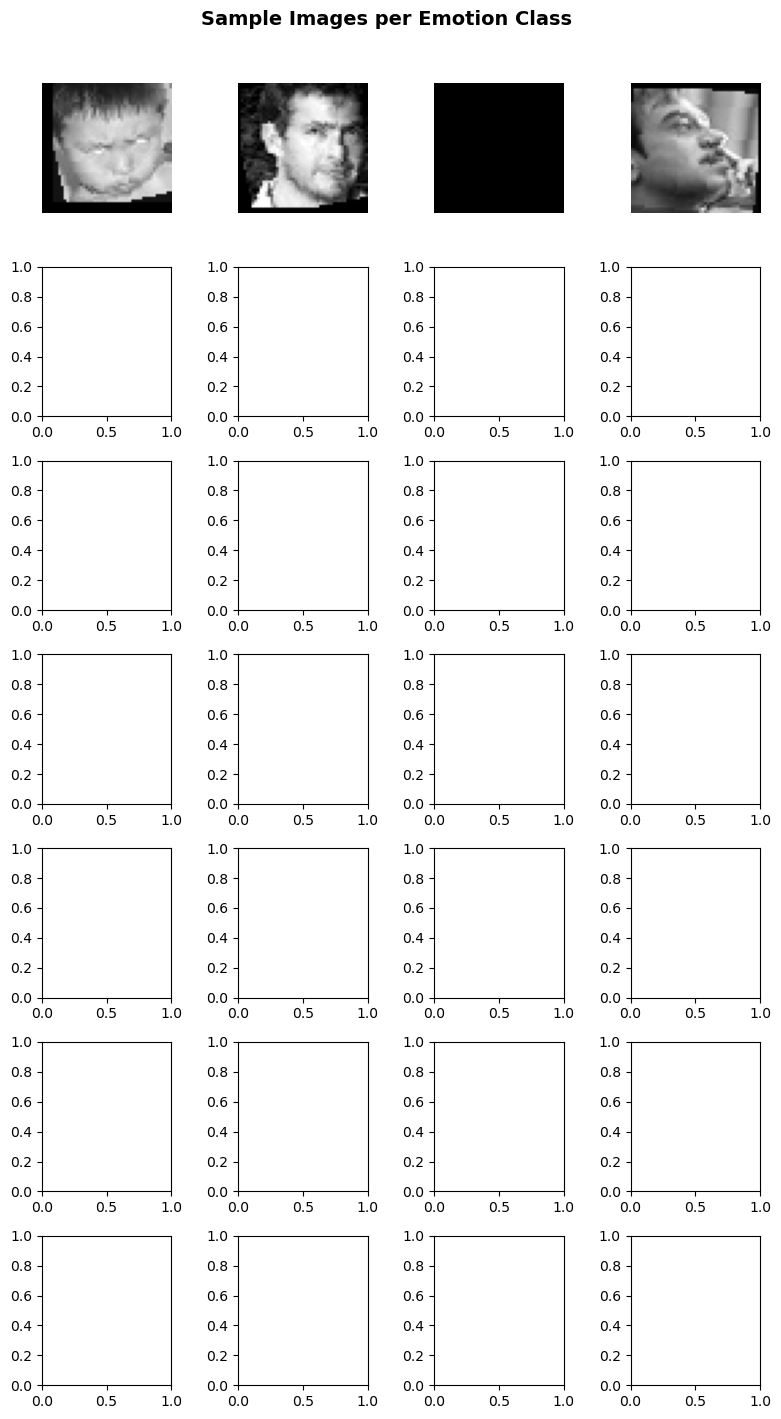

In [5]:
def imshow_batch(dataset, n_per_class: int = 3):
    """Display n_per_class sample images for every emotion."""
    class_to_idx = dataset.class_to_idx
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    
    # Collect samples
    samples = defaultdict(list)
    for img, label in dataset:
        if len(samples[label]) < n_per_class:
            samples[label].append(img)
        if all(len(v) == n_per_class for v in samples.values()):
            break

    fig, axes = plt.subplots(NUM_CLASSES, n_per_class, figsize=(n_per_class * 2, NUM_CLASSES * 2))
    fig.suptitle("Sample Images per Emotion Class", fontsize=14, fontweight='bold', y=1.01)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for row, label_idx in enumerate(sorted(samples.keys())):
        for col, img_tensor in enumerate(samples[label_idx]):
            # De-normalize for display
            img = img_tensor * std + mean
            img = img.permute(1, 2, 0).numpy().clip(0, 1)
            axes[row, col].imshow(img[:, :, 0], cmap='gray')
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(EMOTION_LABELS[label_idx], fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig("samples_per_emotion.png", dpi=120, bbox_inches='tight')
    plt.show()

imshow_batch(full_train_dataset, n_per_class=4)

## 6. Class Distribution Analysis

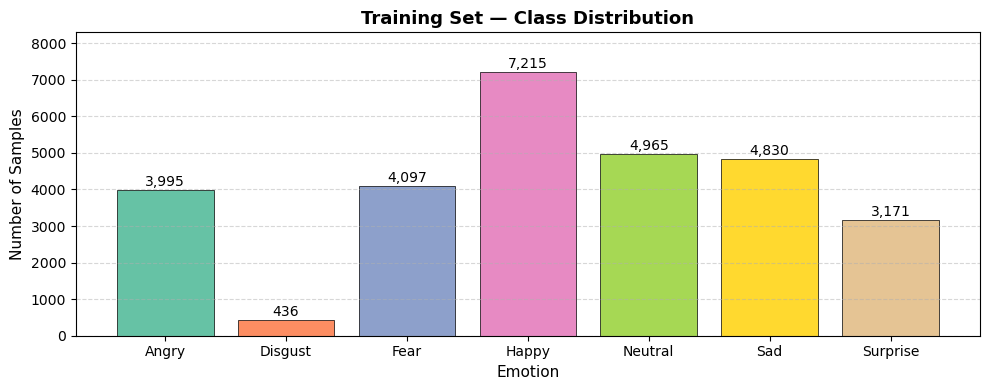

Class distribution:
  Angry     : 3,995  (13.9%)
  Disgust   :   436  (1.5%)
  Fear      : 4,097  (14.3%)
  Happy     : 7,215  (25.1%)
  Neutral   : 4,965  (17.3%)
  Sad       : 4,830  (16.8%)
  Surprise  : 3,171  (11.0%)


In [6]:
# Count samples per class
class_counts = np.bincount(full_train_dataset.targets)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(EMOTION_LABELS, class_counts,
              color=plt.cm.Set2.colors[:NUM_CLASSES], edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f"{count:,}", ha='center', va='bottom', fontsize=10)

ax.set_title("Training Set — Class Distribution", fontsize=13, fontweight='bold')
ax.set_xlabel("Emotion", fontsize=11)
ax.set_ylabel("Number of Samples", fontsize=11)
ax.set_ylim(0, class_counts.max() * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()

print("Class distribution:")
for label, count in zip(EMOTION_LABELS, class_counts):
    pct = 100 * count / class_counts.sum()
    print(f"  {label:10s}: {count:5,}  ({pct:.1f}%)")

## 7. Model — ResNet-18 with Transfer Learning

In [7]:
def build_emotion_model(num_classes: int, freeze_backbone: bool = False) -> nn.Module:
    """
    ResNet-18 pretrained on ImageNet, final FC replaced for emotion classification.
    Optional: freeze backbone layers and only train the classifier head.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    
    in_features = model.fc.in_features   # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )

    return model


model = build_emotion_model(NUM_CLASSES, freeze_backbone=False).to(device)


total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model      : ResNet-18 (ImageNet pretrained)")
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Device          : {device}")

Model      : ResNet-18 (ImageNet pretrained)
Total params    : 11,309,639
Trainable params: 11,309,639
Device          : cuda


## 8. Loss Function, Optimizer & Scheduler

In [8]:

class_counts_tensor = torch.tensor(class_counts, dtype=torch.float32)
class_weights = 1.0 / class_counts_tensor
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_FACTOR,
    patience=LR_PATIENCE
)

print("Criterion : CrossEntropyLoss (weighted + label smoothing 0.1)")
print("Optimizer : AdamW")
print("Scheduler : ReduceLROnPlateau")
print(f"Class weights: {class_weights.cpu().numpy().round(3)}")

Criterion : CrossEntropyLoss (weighted + label smoothing 0.1)
Optimizer : AdamW
Scheduler : ReduceLROnPlateau
Class weights: [0.48  4.398 0.468 0.266 0.386 0.397 0.605]


## 9. Training Loop with Early Stopping

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total



history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'lr':         []
}

best_val_loss = float('inf')
patience_counter = 0

print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>10} {'LR':>10}")
print("-" * 64)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f"{epoch:>6} {train_loss:>12.4f} {train_acc:>9.2f}% {val_loss:>10.4f} {val_acc:>9.2f}% {current_lr:>10.2e}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss':    val_loss,
            'val_acc':     val_acc,
            'config': {
                'num_classes':    NUM_CLASSES,
                'emotion_labels': EMOTION_LABELS,
                'img_size':       IMG_SIZE,
            }
        }, MODEL_SAVE_PATH)
        print(f"  ✓ Best model saved  (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PAT:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

print("\nTraining complete.")

 Epoch   Train Loss  Train Acc   Val Loss    Val Acc         LR
----------------------------------------------------------------
     1       2.0088     22.77%     1.8655     33.63%   1.00e-03
  ✓ Best model saved  (val_loss=1.8655)
     2       1.8823     35.29%     1.8203     41.11%   1.00e-03
  ✓ Best model saved  (val_loss=1.8203)
     3       1.8350     40.75%     1.8355     45.40%   1.00e-03
     4       1.7975     42.77%     1.7348     47.17%   1.00e-03
  ✓ Best model saved  (val_loss=1.7348)
     5       1.7829     45.55%     1.7068     50.65%   1.00e-03
  ✓ Best model saved  (val_loss=1.7068)
     6       1.7623     45.90%     1.7189     52.28%   1.00e-03
     7       1.7508     47.30%     1.6914     53.32%   1.00e-03
  ✓ Best model saved  (val_loss=1.6914)
     8       1.7330     48.55%     1.6576     49.33%   1.00e-03
  ✓ Best model saved  (val_loss=1.6576)
     9       1.7255     49.39%     1.6968     50.63%   1.00e-03
    10       1.7193     49.86%     1.6897     51.35%   

## 10. Training Curves

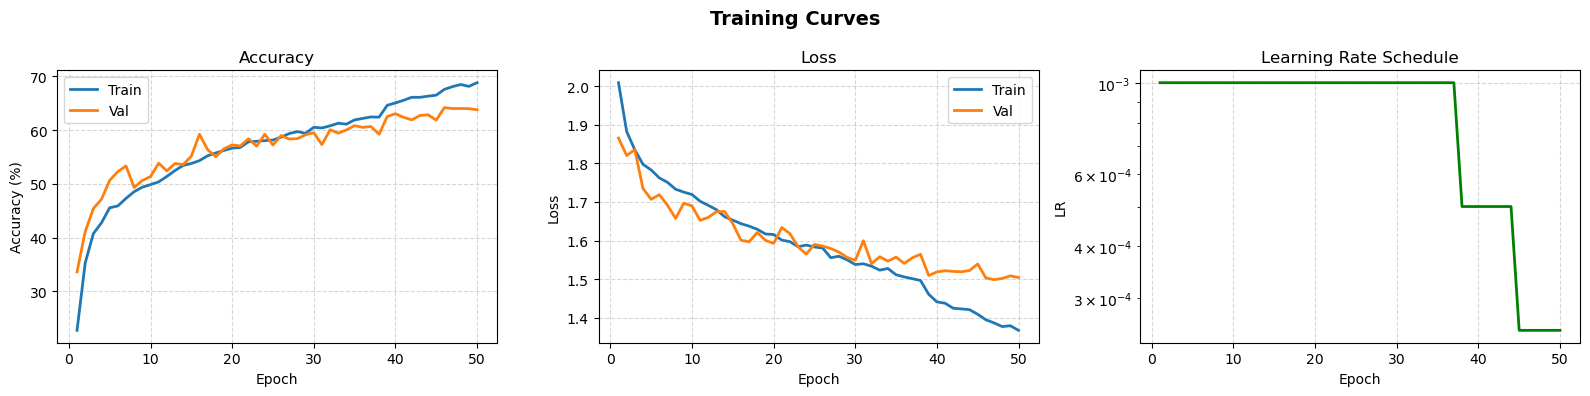

In [10]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training Curves", fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(x, history['train_acc'], label='Train', linewidth=2)
axes[0].plot(x, history['val_acc'],   label='Val',   linewidth=2)
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(linestyle='--', alpha=0.5)

# Loss
axes[1].plot(x, history['train_loss'], label='Train', linewidth=2)
axes[1].plot(x, history['val_loss'],   label='Val',   linewidth=2)
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.5)

# Learning rate
axes[2].plot(x, history['lr'], color='green', linewidth=2)
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].set_yscale('log')
axes[2].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

## 11. Load Best Model & Full Test Evaluation

In [11]:

checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val loss : {checkpoint['val_loss']:.4f}")
print(f"  Val acc  : {checkpoint['val_acc']:.2f}%")
#collecting all test prediction 
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_accuracy = 100.0 * accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_accuracy:.2f}%")

Loaded best model from epoch 47
  Val loss : 1.4989
  Val acc  : 64.00%

Test Accuracy: 64.50%


## 12. Confusion Matrix

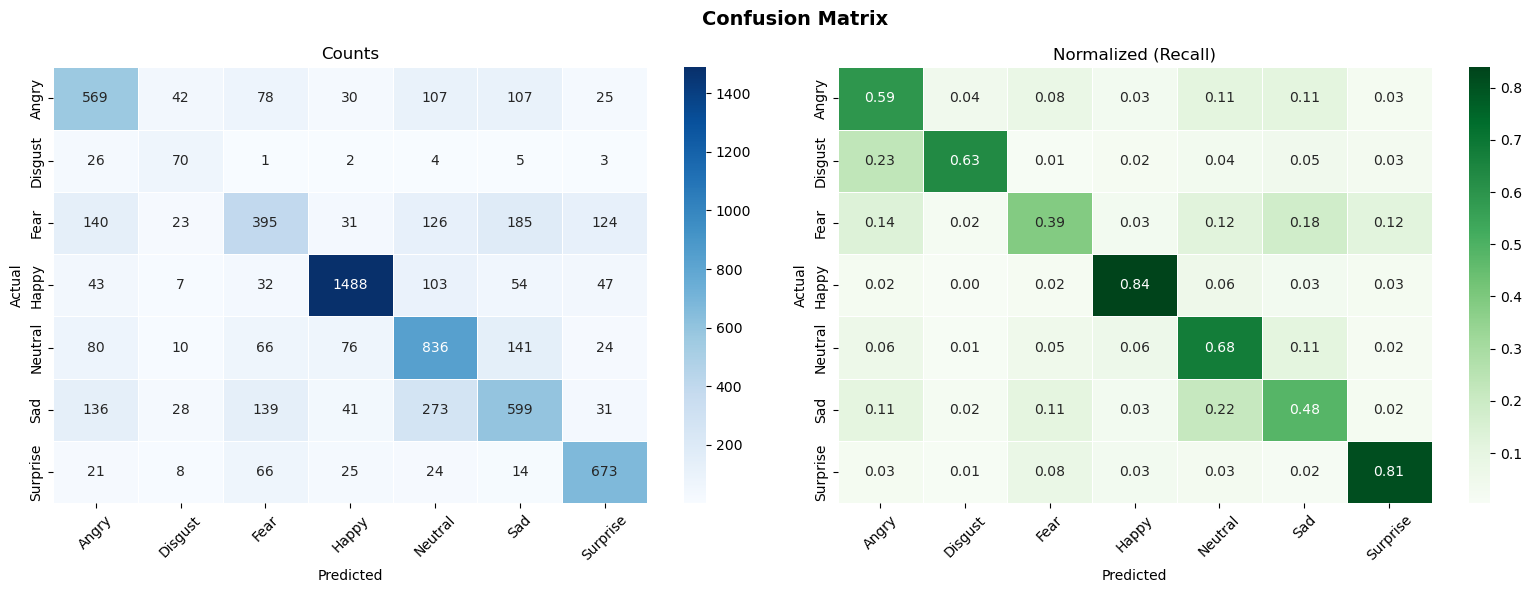

In [12]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # Row-normalize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix", fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Counts")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].tick_params(axis='x', rotation=45)

# Normalized (recall per class)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Normalized (Recall)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

## 13. Per-Class Accuracy Bar Chart

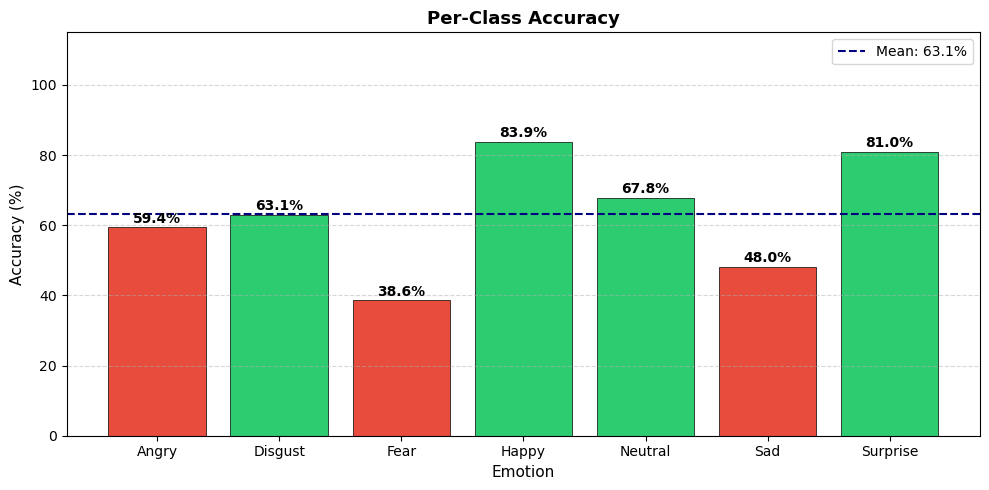

In [13]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)
colors = ['#2ecc71' if acc >= 0.6 else '#e74c3c' for acc in class_accuracy]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(EMOTION_LABELS, class_accuracy * 100, color=colors, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, class_accuracy):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{acc*100:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=class_accuracy.mean() * 100, color='navy', linestyle='--',
           linewidth=1.5, label=f"Mean: {class_accuracy.mean()*100:.1f}%")
ax.set_ylim(0, 115)
ax.set_title("Per-Class Accuracy", fontsize=13, fontweight='bold')
ax.set_xlabel("Emotion", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=120)
plt.show()

## 14. Full Classification Report & Performance Table

In [14]:

print("Classification Report")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                             target_names=EMOTION_LABELS, digits=4))

#Summary metrics table 
metrics = {
    "Metric"   : ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1 Score (weighted)"],
    "Value"    : [
        f"{accuracy_score(all_labels, all_preds)*100:.2f}%",
        f"{precision_score(all_labels, all_preds, average='weighted')*100:.2f}%",
        f"{recall_score(all_labels,   all_preds, average='weighted')*100:.2f}%",
        f"{f1_score(all_labels,       all_preds, average='weighted')*100:.2f}%",
    ]
}
df_metrics = pd.DataFrame(metrics)
print("\nSummary Performance Table")
print(df_metrics.to_string(index=False))

# ─── Model architecture table ──────────────────────────────────────────────
model_table = pd.DataFrame({
    "Component"      : ["Backbone", "Pretrained On", "Head Layer 1", "Head Layer 2", "Output"],
    "Details"        : [
        "ResNet-18 (conv1–layer4)",
        "ImageNet (11M params)",
        "Dropout(0.4) → Linear(512→256) → ReLU",
        "Dropout(0.3) → Linear(256→7)",
        "Softmax — 7 emotion classes",
    ]
})
print("\nModel Architecture")
print(model_table.to_string(index=False))

Classification Report
              precision    recall  f1-score   support

       Angry     0.5606    0.5939    0.5768       958
     Disgust     0.3723    0.6306    0.4682       111
        Fear     0.5084    0.3857    0.4386      1024
       Happy     0.8789    0.8388    0.8584      1774
     Neutral     0.5675    0.6780    0.6179      1233
         Sad     0.5421    0.4804    0.5094      1247
    Surprise     0.7260    0.8099    0.7656       831

    accuracy                         0.6450      7178
   macro avg     0.5937    0.6310    0.6050      7178
weighted avg     0.6460    0.6450    0.6422      7178


Summary Performance Table
              Metric  Value
            Accuracy 64.50%
Precision (weighted) 64.60%
   Recall (weighted) 64.50%
 F1 Score (weighted) 64.22%

Model Architecture
    Component                               Details
     Backbone              ResNet-18 (conv1–layer4)
Pretrained On                 ImageNet (11M params)
 Head Layer 1 Dropout(0.4) → Linear(51

## 15. Test Case Validation (Pass / Fail)

In [15]:
def run_test_cases(model, test_loader, device, n_cases: int = 10):
    """Run structured test cases against the test set and show pass/fail results."""
    model.eval()
    results = []
    count = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(1)

            for i in range(len(labels)):
                pred_idx  = preds[i].item()
                true_idx  = labels[i].item()
                confidence = probs[i][pred_idx].item() * 100
                results.append({
                    "Test Case ID"   : f"TC{count+1:02d}",
                    "Expected"       : EMOTION_LABELS[true_idx],
                    "Predicted"      : EMOTION_LABELS[pred_idx],
                    "Confidence (%)" : f"{confidence:.1f}%",
                    "Result"         : "✓ Pass" if pred_idx == true_idx else "✗ Fail",
                })
                count += 1
                if count >= n_cases:
                    break
            if count >= n_cases:
                break

    df = pd.DataFrame(results)
    pass_rate = (df['Result'] == '✓ Pass').mean() * 100
    print(f"Test Cases (n={n_cases}) — Pass Rate: {pass_rate:.0f}%")
    print(df.to_string(index=False))
    return df

df_tests = run_test_cases(model, test_loader, device, n_cases=15)

Test Cases (n=15) — Pass Rate: 67%
Test Case ID Expected Predicted Confidence (%) Result
        TC01    Angry     Angry          75.6% ✓ Pass
        TC02    Angry     Angry          75.3% ✓ Pass
        TC03    Angry       Sad          53.2% ✗ Fail
        TC04    Angry     Angry          70.1% ✓ Pass
        TC05    Angry     Angry          57.4% ✓ Pass
        TC06    Angry     Angry          56.0% ✓ Pass
        TC07    Angry  Surprise          57.5% ✗ Fail
        TC08    Angry     Angry          76.1% ✓ Pass
        TC09    Angry     Angry          38.2% ✓ Pass
        TC10    Angry     Angry          71.8% ✓ Pass
        TC11    Angry     Angry          67.4% ✓ Pass
        TC12    Angry   Neutral          33.7% ✗ Fail
        TC13    Angry     Angry          36.9% ✓ Pass
        TC14    Angry       Sad          48.7% ✗ Fail
        TC15    Angry      Fear          36.7% ✗ Fail


## 16. Predict on a Single Image File

In [16]:
import cv2
from PIL import Image

def predict_image(image_path: str, model: nn.Module, device, top_k: int = 3):
    """
    Predict emotion from a single image file.
    Returns top-k predictions with confidence scores.
    """
    model.eval()

    img = Image.open(image_path).convert('RGB')
    tensor = eval_transform(img).unsqueeze(0).to(device)  # [1, 3, 48, 48]

    with torch.no_grad():
        outputs = model(tensor)
        probs   = torch.softmax(outputs, dim=1)[0]

    top_probs, top_idxs = probs.topk(top_k)

    print(f"Predictions for: {image_path}")
    print("-" * 35)
    for i, (prob, idx) in enumerate(zip(top_probs, top_idxs)):
        marker = "→" if i == 0 else " "
        print(f"  {marker} {EMOTION_LABELS[idx.item()]:10s}  {prob.item()*100:5.1f}%")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    img_gray = np.array(img.convert('L'))
    axes[0].imshow(img_gray, cmap='gray')
    axes[0].axis('off')
    axes[0].set_title(f"Predicted: {EMOTION_LABELS[top_idxs[0]]} ({top_probs[0]*100:.1f}%)")

    conf_all = probs.cpu().numpy() * 100
    axes[1].barh(EMOTION_LABELS, conf_all,
                 color=['#e74c3c' if i == top_idxs[0] else '#bdc3c7' for i in range(NUM_CLASSES)])
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_title("Emotion Probabilities")
    axes[1].set_xlim(0, 100)
    for i, v in enumerate(conf_all):
        if v > 1:
            axes[1].text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=8)

    plt.tight_layout()
    plt.show()
    return EMOTION_LABELS[top_idxs[0]]


# ─── Usage ─────────────────────────────────────────────────────────────────
# predict_image("test.jpg", model, device)
print("predict_image() function ready. Call it with any .jpg / .png file path.")

predict_image() function ready. Call it with any .jpg / .png file path.


## 17. Real-Time Webcam Inference (OpenCV)

In [17]:
def run_webcam_inference(model: nn.Module, device, duration_sec: int = 60):
    """
    Real-time emotion detection from webcam.
    - Uses OpenCV Haar Cascade for face detection.
    - Overlays detected emotion + confidence on each face.
    - Press 'q' to quit early.
    """
    import time
    model.eval()

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )

    # PIL-based transform for webcam frames
    webcam_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Could not open webcam.")
        return

    COLORS = [
        (255, 80,  80),   # Angry   — red
        (180, 80, 255),   # Disgust — purple
        (255, 165,  0),   # Fear    — orange
        (80, 255,  80),   # Happy   — green
        (180, 180, 180),  # Neutral — gray
        (80,  80, 255),   # Sad     — blue
        (255, 255,  80),  # Surprise— yellow
    ]

    start = time.time()
    print("Webcam inference running. Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
        )

        for (x, y, w, h) in faces:
            face_img = gray[y:y+h, x:x+w]
            pil_face  = Image.fromarray(face_img)
            tensor    = webcam_transform(pil_face).unsqueeze(0).to(device)

            with torch.no_grad():
                outputs = model(tensor)
                probs   = torch.softmax(outputs, dim=1)[0]
                pred_idx = probs.argmax().item()

            emotion    = EMOTION_LABELS[pred_idx]
            confidence = probs[pred_idx].item() * 100
            color      = COLORS[pred_idx]

            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
            label = f"{emotion} {confidence:.0f}%"
            cv2.putText(frame, label, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

            # Mini probability bar
            bar_x = x + w + 5
            for i, (em_label, prob) in enumerate(zip(EMOTION_LABELS, probs.cpu().numpy())):
                bar_w = int(prob * 80)
                by = y + i * 18
                cv2.rectangle(frame, (bar_x, by), (bar_x + bar_w, by + 14),
                              COLORS[i] if i == pred_idx else (200, 200, 200), -1)
                cv2.putText(frame, em_label[:3], (bar_x + 85, by + 12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1)

        cv2.imshow('Emotion Detection — Press q to quit', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        if time.time() - start > duration_sec:
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Webcam session ended.")



print("run_webcam_inference() ready. Uncomment the last line to launch.")

run_webcam_inference() ready. Uncomment the last line to launch.


## 18. Save & Load Model — Portable Checkpoint

In [18]:
def load_emotion_model(checkpoint_path: str, device) -> nn.Module:
    """Load a saved emotion model from checkpoint. No need to rebuild manually."""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    cfg = checkpoint['config']

    model = build_emotion_model(cfg['num_classes']).to(device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()

    print(f"Model loaded from '{checkpoint_path}'")
    print(f"  Trained for : {checkpoint['epoch']} epochs")
    print(f"  Val loss    : {checkpoint['val_loss']:.4f}")
    print(f"  Val acc     : {checkpoint['val_acc']:.2f}%")
    print(f"  Classes     : {cfg['emotion_labels']}")
    return model


# Verification of saved model
loaded_model = load_emotion_model(MODEL_SAVE_PATH, device)
test_loss, test_acc = evaluate(loaded_model, test_loader, criterion, device)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")
print(f"Final Test Loss    : {test_loss:.4f}")

Model loaded from 'emotion_resnet18_best.pth'
  Trained for : 47 epochs
  Val loss    : 1.4989
  Val acc     : 64.00%
  Classes     : ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

Final Test Accuracy: 64.50%
Final Test Loss    : 1.6125


## 19. Final Project Summary

In [19]:
from datetime import datetime

acc  = accuracy_score(all_labels, all_preds) * 100
prec = precision_score(all_labels, all_preds, average='weighted') * 100
rec  = recall_score(all_labels,   all_preds, average='weighted') * 100
f1   = f1_score(all_labels,       all_preds, average='weighted') * 100

summary = pd.DataFrame({
    "Item"  : [
        "Model", "Backbone", "Pretrained", "Dataset",
        "Classes", "Train samples", "Test samples",
        "Test Accuracy", "Precision (w)", "Recall (w)", "F1 Score (w)",
        "Optimizer", "Loss Function", "Scheduler",
        "Best checkpoint", "Generated"
    ],
    "Value" : [
        "EmotionNet (ResNet-18)", "ResNet-18", "ImageNet", "FER-2013",
        ", ".join(EMOTION_LABELS), f"{train_size:,}", f"{len(test_dataset):,}",
        f"{acc:.2f}%", f"{prec:.2f}%", f"{rec:.2f}%", f"{f1:.2f}%",
        "AdamW + ReduceLROnPlateau",
        "CrossEntropy (weighted, label_smoothing=0.1)",
        "ReduceLROnPlateau (patience=5, factor=0.5)",
        MODEL_SAVE_PATH,
        datetime.now().strftime("%Y-%m-%d %H:%M")
    ]
})

print("=" * 60)
print("  EMOTION DETECTION — PROJECT SUMMARY")
print("=" * 60)
print(summary.to_string(index=False))
print("=" * 60)
print("\nOutputs saved:")
for f in ["emotion_resnet18_best.pth", "training_curves.png",
          "confusion_matrix.png", "per_class_accuracy.png",
          "class_distribution.png", "samples_per_emotion.png"]:
    print(f"  {f}")

  EMOTION DETECTION — PROJECT SUMMARY
           Item                                               Value
          Model                              EmotionNet (ResNet-18)
       Backbone                                           ResNet-18
     Pretrained                                            ImageNet
        Dataset                                            FER-2013
        Classes Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise
  Train samples                                              24,403
   Test samples                                               7,178
  Test Accuracy                                              64.50%
  Precision (w)                                              64.60%
     Recall (w)                                              64.50%
   F1 Score (w)                                              64.22%
      Optimizer                           AdamW + ReduceLROnPlateau
  Loss Function        CrossEntropy (weighted, label_smoothing=0.1)
      Sche